**Recognizing Handwritten Digits Using Scikit-learn**


Scikit-learn is one of the most popular and easy-to-use machine learning libraries in Python. It provides many useful tools that help developers build and train machine learning models easily.

In this project, we will use **Scikit-learn to train an MLP (Multi-Layer Perceptron) model** on the **Handwritten Digits dataset**.

Some key benefits of Scikit-learn are:

* It provides many machine learning algorithms for **classification, regression, and clustering**.
* It includes algorithms such as **SVM, Random Forest, Gradient Boosting, and K-Means**.
* It works well with popular Python libraries such as **NumPy and SciPy**.
* It provides simple and easy-to-use functions for building and evaluating machine learning models.


### Importing Libraries and Dataset

First, we will import the required libraries and load the **Handwritten Digits dataset**.


In [1]:
# importing the hand written digit dataset
from sklearn import datasets

# digit contain the dataset
digits = datasets.load_digits()

# dir function use to display the attributes of the dataset
dir(digits)

['DESCR', 'data', 'feature_names', 'frame', 'images', 'target', 'target_names']

### Function to Print a Set of Images

The `digits.images` array contains all the handwritten digit images.

* There are **1,797 images** in the dataset.
* Each image has **8 × 8 pixels**, which means **64 pixels** in total.
* The first dimension represents the number of images.
* The next two dimensions represent the **rows and columns of each image**.
* So, we can think of the dataset as a collection of **8 × 8 pixel images**.


In [2]:
# outputting the picture value as a series of numbers
print(digits.images[0])

[[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]]


The original digit images had a higher resolution, but they were reduced to **8 × 8 pixels** for the Scikit-learn dataset. This makes the data smaller and helps the machine learning model train **faster and more easily**.

However, because the images have low resolution, some digits can be difficult even for humans to recognize. This low image quality can also affect the performance of the neural network.

The main goal is to see whether the neural network can recognize the digits **as well as a human**. Achieving similar performance would already be a good result.


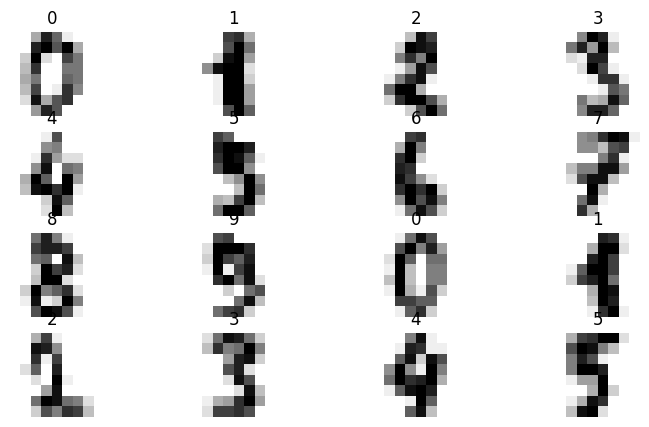

In [10]:
import matplotlib.pyplot as plt

def plot_multi(i):
    nplots = 16
    fig = plt.figure(figsize=(9, 5))

    for j in range(nplots):
        plt.subplot(4, 4, j + 1)
        plt.imshow(digits.images[i + j], cmap='binary')
        plt.title(digits.target[i + j])
        plt.axis('off')

    plt.show()

plot_multi(0)

### Training Neural Network with the Dataset

A **neural network** is a machine learning model that learns patterns from data, similar to the way the human brain processes information.

In this project, the neural network takes the **handwritten digit images** as input and learns to recognize digits from **0 to 9**.

* The **input layer has 64 nodes**, because each image contains **64 pixels (8 × 8)**.
* Each node represents the value of one pixel.
* The network passes these values to the next layer to learn patterns.
* This is a **dense neural network**, which means every node in one layer is connected to all the nodes in the next layer.


The input layer needs the data in a **one-dimensional format**, but the digit images are stored as **two-dimensional 8 × 8 arrays**. Therefore, we need to **flatten each image into a one-dimensional array** before training the neural network.


In [11]:
# converting the 2 dimensional array to one dimensional array
y = digits.target
x = digits.images.reshape((len(digits.images), -1))

# gives the  shape of the data
x.shape

(1797, 64)

The **8 × 8 image** is converted into a **one-dimensional array** by placing all the pixel values in a single row.

So, each image changes from **8 × 8 = 64 pixels** into a **1-D array containing 64 values**.


In [12]:
# printing the one-dimensional array's values
x[0]

array([ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,  0.,  0., 13., 15., 10.,
       15.,  5.,  0.,  0.,  3., 15.,  2.,  0., 11.,  8.,  0.,  0.,  4.,
       12.,  0.,  0.,  8.,  8.,  0.,  0.,  5.,  8.,  0.,  0.,  9.,  8.,
        0.,  0.,  4., 11.,  0.,  1., 12.,  7.,  0.,  0.,  2., 14.,  5.,
       10., 12.,  0.,  0.,  0.,  0.,  6., 13., 10.,  0.,  0.,  0.])

### Data Split for Training and Testing

The dataset is divided into two parts: **training data** and **testing data**.

* **Training data** is used to train the machine learning model.
* **Testing data** is used to check how well the model performs on new, unseen data.

This **train-test split** helps us measure the model's performance and check whether it can make accurate predictions on data it has not seen before.


In [14]:
# Very first 1000 photographs and
# labels will be used in training.
x_train = x[:1000]
y_train = y[:1000]

# The leftover dataset will be utilised to
# test the network's performance later on.
x_test = x[1000:]
y_test = y[1000:]

### Using the Multi-Layer Perceptron (MLP) Classifier

**MLP** stands for **Multi-Layer Perceptron**. It is a type of neural network made up of multiple layers of connected neurons.

Each neuron receives information from the previous layer, processes it, and passes the result to the next layer. This allows the network to **learn patterns from the input data and make predictions**.


In [15]:
# importing the MLP classifier from sklearn
from sklearn.neural_network import MLPClassifier

# calling the MLP classifier with specific parameters
mlp = MLPClassifier(hidden_layer_sizes=(15,),
                    activation='logistic',
                    alpha=1e-4, solver='sgd',
                    tol=1e-4, random_state=1,
                    learning_rate_init=.1,
                    verbose=True)

### Training the MLP Model

Now, we will **train the MLP model using the training data**. The model will learn patterns from the handwritten digit images so that it can recognize digits correctly.


In [16]:
mlp.fit(x_train, y_train)

Iteration 1, loss = 2.22958289
Iteration 2, loss = 1.91207743
Iteration 3, loss = 1.62507727
Iteration 4, loss = 1.32649842
Iteration 5, loss = 1.06100535
Iteration 6, loss = 0.83995513
Iteration 7, loss = 0.67806075
Iteration 8, loss = 0.55175832
Iteration 9, loss = 0.45840445
Iteration 10, loss = 0.39149735
Iteration 11, loss = 0.33676351
Iteration 12, loss = 0.29059880
Iteration 13, loss = 0.25437208
Iteration 14, loss = 0.22838372
Iteration 15, loss = 0.20200554
Iteration 16, loss = 0.18186565
Iteration 17, loss = 0.16461183
Iteration 18, loss = 0.14990228
Iteration 19, loss = 0.13892154
Iteration 20, loss = 0.12833784
Iteration 21, loss = 0.12138920
Iteration 22, loss = 0.11407971
Iteration 23, loss = 0.10677664
Iteration 24, loss = 0.10037149
Iteration 25, loss = 0.09593187
Iteration 26, loss = 0.09250135
Iteration 27, loss = 0.08676698
Iteration 28, loss = 0.08356043
Iteration 29, loss = 0.08209789
Iteration 30, loss = 0.07649168
Iteration 31, loss = 0.07410898
Iteration 32, los

MLPClassifier(activation='logistic', hidden_layer_sizes=(15,),
              learning_rate_init=0.1, random_state=1, solver='sgd',
              verbose=True)

Above shown is the loss for the last five epochs of the MLPClassifier and its respective configuration.

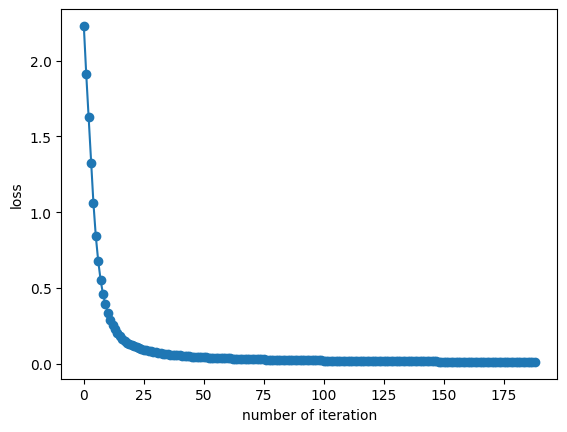

In [17]:
fig, axes = plt.subplots(1, 1)
axes.plot(mlp.loss_curve_, 'o-')
axes.set_xlabel("number of iteration")
axes.set_ylabel("loss")
plt.show()

### Model Evaluation

Now, we will check how well the model performs on **unseen testing data**. This helps us understand whether the model has actually learned the patterns of handwritten digits or simply memorized the training data.


In [18]:
predictions = mlp.predict(x_test)
predictions[:50]

array([1, 4, 0, 5, 3, 6, 9, 6, 1, 7, 5, 4, 4, 7, 2, 8, 2, 2, 5, 7, 9, 5,
       4, 4, 9, 0, 8, 9, 8, 0, 1, 2, 3, 4, 5, 6, 7, 8, 3, 0, 1, 2, 3, 4,
       5, 6, 7, 8, 5, 0])

But the **actual labels**, also called **ground truth labels**, are shown below.


In [19]:
y_test[:50]

array([1, 4, 0, 5, 3, 6, 9, 6, 1, 7, 5, 4, 4, 7, 2, 8, 2, 2, 5, 7, 9, 5,
       4, 4, 9, 0, 8, 9, 8, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 3, 4,
       5, 6, 7, 8, 9, 0])

By comparing the **predicted labels** with the **ground truth labels**, we can calculate the **accuracy of our model**.


In [20]:
# importing the accuracy_score from the sklearn
from sklearn.metrics import accuracy_score

# calculating the accuracy with y_test and predictions
accuracy_score(y_test, predictions)

0.9146800501882058

### Conclusion

In this project, we used **Scikit-learn to recognize handwritten digits** using the Digits dataset. We prepared the images, converted them into a suitable format, split the data into training and testing sets, and trained an **MLP (Multi-Layer Perceptron) classifier**.

Finally, we evaluated the model using the testing data by comparing its predictions with the actual labels. This helped us measure how accurately the model can recognize handwritten digits.

Overall, this project shows how a **neural network can learn patterns from image data and classify handwritten digits effectively**.
